# EX2 — PID refresher: one motor, three knobs

**What you will see**
* The *discrete* PID update — the only version you will ever type.
* Kp alone leaves an offset under load; Ki removes it (and can overshoot); Kd damps.
* Three presets you can click through, plus sliders if `ipywidgets` is installed.

Plant: a single wheel **position** loop — exactly what the mouse's forward and heading loops are.
The motor is a first-order lag `v -> Km * u` with time constant `Tm` (same model as EX1); position is its
integral. Setpoint = one cell (180 mm). From t = 1.2 s a "hill" (load) tries to push the wheel back.

Units here are mm for readability; on the mouse the same loop runs on encoder counts (EX3).
The derivative acts on the *measurement* (not the error) so the setpoint jump does not cause a kick.

In [39]:
from mouse_sim import *

cfg = Config()

## The four lines that matter

```
e      = setpoint - measured
integ += e * dt                      # unless saturated (anti-windup, see EX6)
deriv  = (e - e_prev) / dt           # filtered in practice
u      = Kp*e + Ki*integ + Kd*deriv  # then clamp to what the motor can take
```
`mouse_sim.PID` implements exactly this (with the clamp and a filtered derivative).

### Discrete PID
From the continuous PID law to the four lines of code

$$
u(t) = K_p\, e(t) \;+\; K_i \int_0^t e(\tau)\, d\tau \;+\; K_d \frac{de(t)}{dt}
$$

$$
u(t) = K_p e(t) + K_i\!\int_0^t\! e\,d\tau + K_d\frac{de}{dt}
\qquad\longrightarrow\qquad
\begin{aligned}
&\texttt{integ += e * dt} \\
&\texttt{deriv = (e - e\_prev) / dt} \\
&\texttt{u = Kp*e + Ki*integ + Kd*deriv}
\end{aligned}
$$

- **P** — no approximation needed, just the current sample.
- **I** — an integral is "area under the curve." With only samples, the computer approximates that area
  as a running sum of thin rectangles: `e * dt` each tick, added to a total.
- **D** — a derivative is "instantaneous slope," which needs `dt → 0`. The computer can't do that, so it
  takes the slope between *this* sample and the *previous* one instead — the smallest step it actually has.
- **Same law, sampled every `dt`.** Smaller `dt` → better approximation, but `Ki`/`Kd` are only valid *for
  that `dt`* — change the loop rate, retune.

In [40]:
def run_position_loop(kp, ki, kd, load=0.25, target_mm=180.0, t_end=2.5, tf=0.002, v_batt=8.4):
    """One wheel POSITION loop (this is what the mouse's forward/heading loops are).
    Setpoint: a 1-cell step (180 mm) at t = 0.05 s.  From t = 1.2 s a 'hill' (load) tries to
    push the wheel backwards.  Returns t, x [mm], u [PWM], ref [mm]."""
    c = replace(cfg, v_batt=v_batt)
    mot = Motor(c)
    pid = PID(kp, ki, kd, tf=tf, umin=-255, umax=255, d_on_measurement=True)
    t = np.arange(0, t_end, c.dt)
    x, u, ref = np.zeros_like(t), np.zeros_like(t), np.zeros_like(t)
    pos = 0.0
    for i, ti in enumerate(t):
        mot.load = load if ti >= 1.2 else 0.0
        ref[i] = target_mm if ti >= 0.05 else 0.0
        u[i] = pid.update(ref[i] - pos, c.dt, y=pos)
        pos += mot.step(u[i]) * c.wheel_r * 1000 * c.dt
        x[i] = pos
    return t, x, u, ref


def metrics(t, x, ref, target=180.0):
    """Overshoot % and 2 % settling time of the step (before the load at 1.2 s), error after load."""
    sel = t < 1.2
    xx = x[sel]
    overshoot = max(0.0, (xx.max() - target) / target * 100)
    band = 0.02 * target
    outside = np.where(np.abs(xx - target) > band)[0]
    ts = t[sel][outside[-1]] if len(outside) else 0.0
    err_after_load = target - x[-1]
    return overshoot, ts, err_after_load


def show(kp, ki, kd, title=None, fname=None):
    t, x, u, ref = run_position_loop(kp, ki, kd)
    ov, ts, sse = metrics(t, x, ref)
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.5, 5.2), sharex=True)
    a1.plot(t, ref, "k--", lw=1, label="setpoint (1 cell)")
    a1.plot(t, x, lw=1.8, label="wheel position")
    a1.axvline(1.2, color="tab:red", ls=":", lw=1); a1.text(1.22, 10, "load applied (hill)", color="tab:red")
    a1.set_ylabel("position [mm]"); a1.grid(alpha=0.3); a1.legend(loc="lower right")
    a1.set_title(title or f"Kp={kp}, Ki={ki}, Kd={kd}   |   overshoot {ov:.1f} %, settle(2%) {ts*1000:.0f} ms, error after load {sse:+.1f} mm")
    a2.plot(t, u, lw=1.5, color="tab:orange"); a2.set_ylabel("PWM"); a2.set_ylim(-260, 260); a2.grid(alpha=0.3)
    a2.set_xlabel("time [s]")
    fig.tight_layout()
    if fname:
        savefig(fig, fname)
    plt.show()
    return ov, ts, sse

## Preset 1 — P only
Fast, but it overshoots (the motor lag lets it coast past the target) and, once the hill pushes back,
it settles **short of the target**: Kp needs an error to produce any output at all.

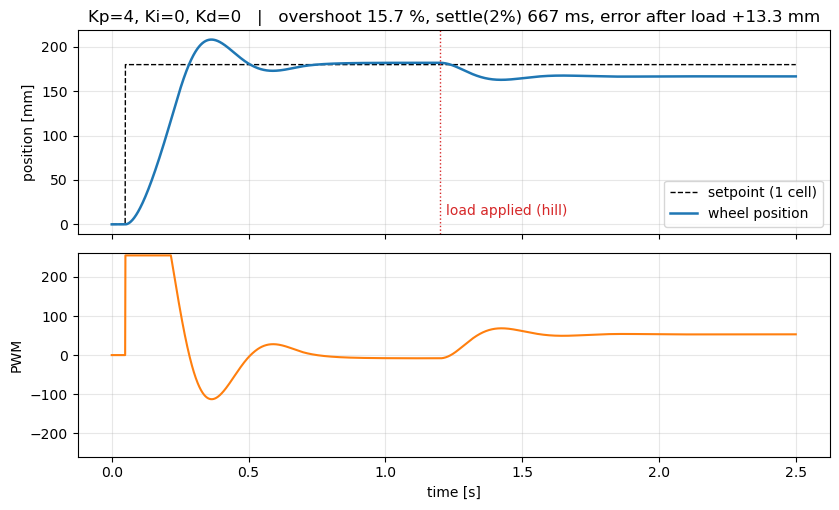

In [41]:
show(4, 0, 0, fname="ex02_preset1_P.png");

## Preset 2 — P + I
Same Kp as Preset 1. Adding Ki: the integrator keeps pushing while an error persists, so the **offset under load disappears** (+13.3 mm → +0.4 mm). Price: a little more overshoot and a longer settling time — the integrator is still "catching up" from the approach, and that surplus has to bleed off before the position settles. D is not here yet: nothing is damping that surplus.

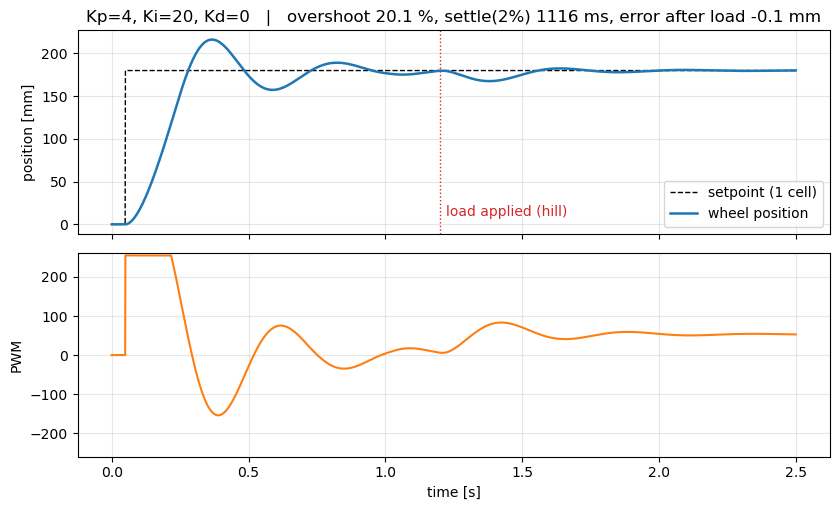

In [42]:
show(4, 20, 0, fname="ex02_preset2_PI.png");

## Preset 3 — P + D
D looks at how fast the position is changing and brakes early → overshoot almost gone.
The offset under load is still there: D does nothing for a constant error.

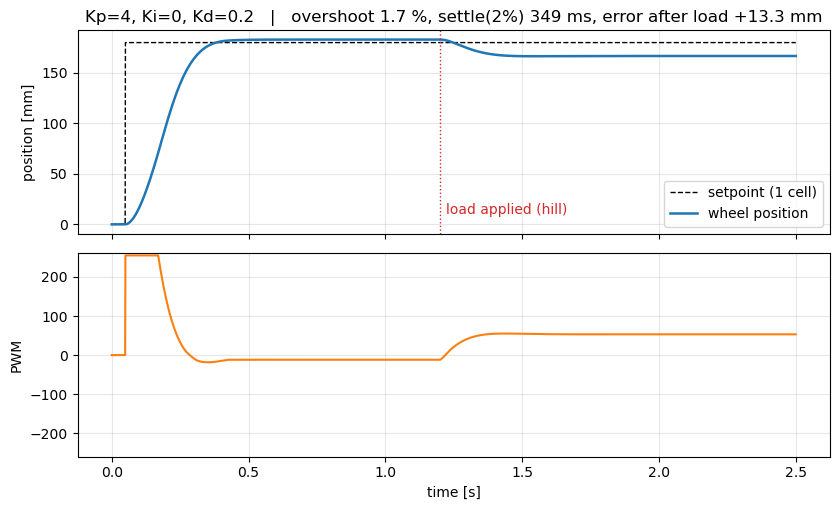

In [43]:
show(4, 0, 0.2, fname="ex02_preset2_PD.png");

## Preset 4 — P + I + D
The integrator keeps pushing while an error persists → the offset under load disappears.
Price: a little more overshoot on the step (the integrator winds up while the wheel is still far away).

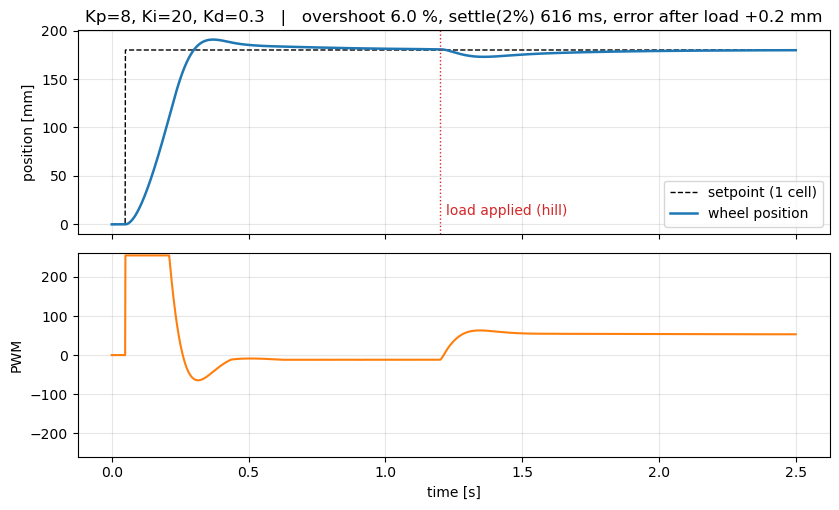

In [44]:
show(8, 20, 0.3, fname="ex02_preset3_PID.png");

## Preset 4 — too much I
What "the integrator is fighting me" looks like: it rings around the target and never settles.
This is why the tuning order is **P → D → I**, and I is added last and small (EX6).

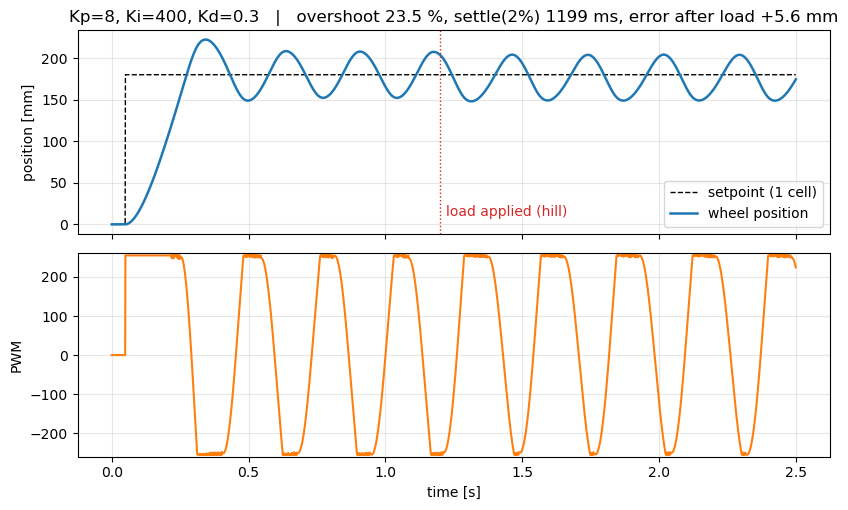

In [45]:
show(8, 400, 0.3, fname="ex02_preset4_too_much_I.png");

## Sliders (optional — needs `ipywidgets`)

In [46]:
try:
    from ipywidgets import interact, FloatSlider
    interact(lambda Kp, Ki, Kd: show(Kp, Ki, Kd),
             Kp=FloatSlider(4, min=0, max=30, step=0.5),
             Ki=FloatSlider(0, min=0, max=500, step=5),
             Kd=FloatSlider(0, min=0, max=1.0, step=0.02))
except ImportError:
    print("ipywidgets not installed — use the presets above (pip install ipywidgets).")

interactive(children=(FloatSlider(value=4.0, description='Kp', max=30.0, step=0.5), FloatSlider(value=0.0, des…

## Effect summary (what to memorise)

| increase | rise time | overshoot | settling | steady-state error | stability |
|---|---|---|---|---|---|
| Kp | ↓ | ↑ | small ↑ | ↓ | ↓ |
| Ki | small ↓ | ↑ | ↑ | **removed** | ↓ |
| Kd | small ↓ | ↓ | ↓ | ~ | ↑ |

## On your mouse
* Gains here are "PWM per mm" / "PWM per mm·s" / "PWM per mm/s". Your loops run on encoder counts
  ("PWM per count") — different numbers (divide by counts/mm), same four lines.
* `Ki` and `Kd` scale with the loop period. Change `dt` and you must retune.